<a href="https://colab.research.google.com/github/sap-tarshi-ghosh/Image-Processing-Tutorial/blob/main/code/04_Color_space.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
img1 = cv2.imread('/content/Alternaria Leaf Spot (100).jpg')
img2 = cv2.imread('/content/Alternaria Leaf Spot (101).jpg')
img3 = cv2.imread('/content/Alternaria Leaf Spot (105).jpg')
img4 = cv2.imread('/content/Leaf Spot (100).jpg')

# Convert BGR (OpenCV default) → RGB
img1 = cv2.cvtColor(img1, cv2.COLOR_BGR2RGB)
img2 = cv2.cvtColor(img2, cv2.COLOR_BGR2RGB)
img3 = cv2.cvtColor(img3, cv2.COLOR_BGR2RGB)
img4 = cv2.cvtColor(img4, cv2.COLOR_BGR2RGB)

images = [img1, img2, img3, img4]

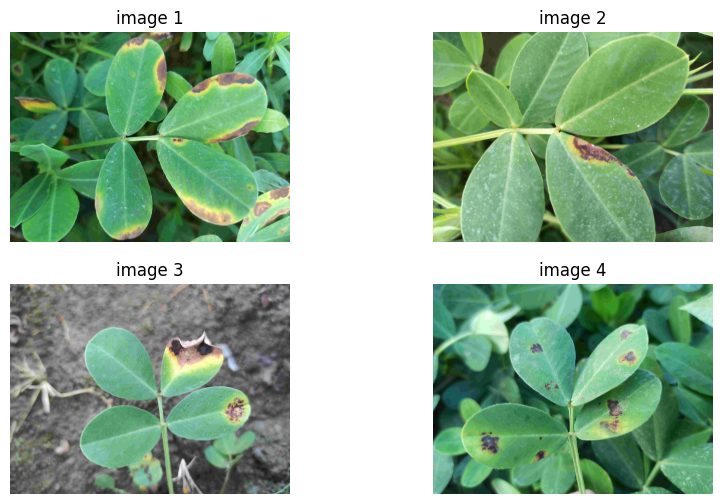

In [ ]:
plt.figure(figsize=(10,6))

for i,img in enumerate(images):
    plt.subplot(2,2,i+1)
    plt.imshow(img)
    plt.title(f"image {i+1}")
    plt.axis("off")

plt.show()

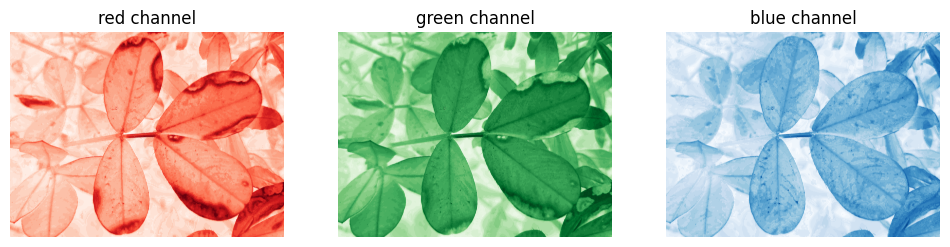

In [ ]:
def show_rgb_channels(img):

    R = img[:,:,0]
    G = img[:,:,1]
    B = img[:,:,2]

    plt.figure(figsize=(12,4))

    plt.subplot(1,3,1)
    plt.imshow(R, cmap='Reds')
    plt.title("red channel")
    plt.axis("off")

    plt.subplot(1,3,2)
    plt.imshow(G, cmap='Greens')
    plt.title("green channel")
    plt.axis("off")

    plt.subplot(1,3,3)
    plt.imshow(B, cmap='Blues')
    plt.title("blue channel")
    plt.axis("off")

    plt.show()

show_rgb_channels(img1)

RGB to CMYK

In [ ]:
def rgb_to_cmyk(image):

    #normalize RGB to [0,1]
    img = image.astype(float) / 255

    R = img[:,:,0]
    G = img[:,:,1]
    B = img[:,:,2]

    #computing the black channel
    K = 1 - np.maximum.reduce([R, G, B])

    #avoid division by zero
    denominator = (1 - K)
    denominator[denominator == 0] = 1

    C = (1 - R - K) / denominator
    M = (1 - G - K) / denominator
    Y = (1 - B - K) / denominator

    #stack channels
    CMYK = np.stack((C, M, Y, K), axis=2)

    return CMYK

In [ ]:
cmyk_image = rgb_to_cmyk(img1)

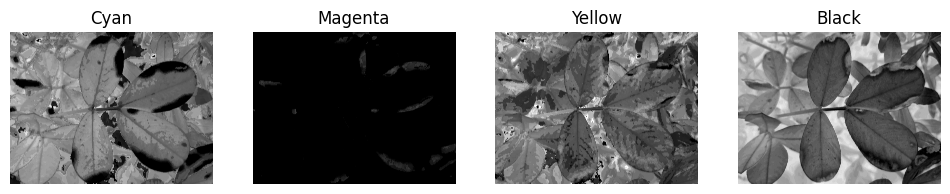

In [ ]:
import matplotlib.pyplot as plt

titles = ["Cyan", "Magenta", "Yellow", "Black"]

plt.figure(figsize=(12,4))

for i in range(4):
    plt.subplot(1,4,i+1)
    plt.imshow(cmyk_image[:,:,i], cmap='gray')
    plt.title(titles[i])
    plt.axis("off")

plt.show()

RGB to HSV

In [ ]:
def rgb_to_hsv(image):

    img = image.astype(np.float32) / 255

    R = img[:,:,0]
    G = img[:,:,1]
    B = img[:,:,2]

    num = 0.5*((R-G)+(R-B))
    den = np.sqrt((R-G)**2 + (R-B)*(G-B)) + 1e-6

    theta = np.arccos(num/den)

    H = np.where(B<=G, theta, 2*np.pi-theta)
    H = H/(2*np.pi)

    S = 1 - (3*np.minimum(np.minimum(R,G),B)/(R+G+B+1e-6))

    I = (R+G+B)/3

    return H,S,I

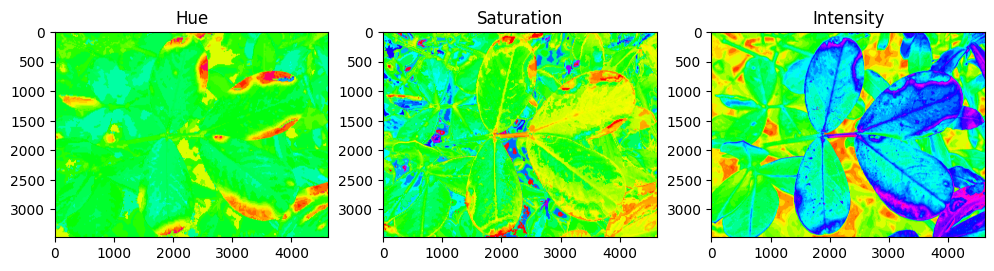

In [ ]:
H,S,I = rgb_to_hsv(img1)

plt.figure(figsize=(12,4))

plt.subplot(1,3,1)
plt.imshow(H, cmap='hsv')
plt.title("Hue")

plt.subplot(1,3,2)
plt.imshow(S, cmap='hsv')
plt.title("Saturation")

plt.subplot(1,3,3)
plt.imshow(I, cmap='hsv')
plt.title("Intensity")

plt.show()